<a href="https://colab.research.google.com/github/NAlfassal/Assignments_W-4/blob/main/WeeklyProject_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Weekly Project: Image Classification with Transfer Learning

In this project, you will build a complete image classification pipeline using transfer learning. You'll work with the dataset provided by your instructor.

**Learning Objectives:**
- Load and prepare image datasets for deep learning
- Use pre-trained models for transfer learning
- Implement two transfer learning strategies: fine-tuning and feature extraction
- Evaluate model performance
- Deploy models using ONNX for production (Optional)

**References:**

- [Training with PyTorch](https://docs.pytorch.org/tutorials/beginner/introyt/trainingyt.html)
- [PyTorch Transfer Learning Tutorial](https://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html)

## Table of Contents

1. [Data Ingestion](#1)
2. [Data Preparation](#2)
3. [Model Building](#3)
4. [Training](#4)
   - [4.1 ConvNet as Fixed Feature Extractor](#4-1)
   - [4.2 Fine-tuning the ConvNet](#4-2)
5. [Evaluation](#5)
6. [Inference on Custom Images](#6)
7. [Deployment (ONNX)](#7)

## Imports

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
import os

## Setup Device

**Note: you will need a GPU; so please run this on Colab and specify a GPU runtime (e.g., T4-GPU)**

In [ ]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


<a name='1'></a>
## 1. Data Ingestion

**Task**: The dataset should be downloaded and extracted to a local directory.

**References:**

- [Dataset and DataLoader](https://docs.pytorch.org/tutorials/beginner/introyt/trainingyt.html#dataset-and-dataloader)
- [torchvision.datasets.ImageFolder](https://pytorch.org/vision/stable/generated/torchvision.datasets.ImageFolder.html)

In [ ]:
%%writefile kaggle.json
{
  "username": "nadaalialfassal",
  "key": "KGAT_c82f0f718ff7551fe8b93b18c7ca3d8d"
}

Writing kaggle.json


In [ ]:

import os

# Create Kaggle folder and set permissions
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download and unzip the dataset using the API
!kaggle datasets download -d puneet6060/intel-image-classification
!unzip -q intel-image-classification.zip

# Define paths for the project
train_dir = 'seg_train/seg_train'
test_dir = 'seg_test/seg_test'
pred_dir = 'seg_pred/seg_pred'

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
 83% 288M/346M [00:00<00:00, 859MB/s] 
100% 346M/346M [00:00<00:00, 719MB/s]


**Task**: create a `train_dataset` and `test_dataset` (without transforms for now).

In [ ]:
train_dataset = datasets.ImageFolder(root=train_dir)
test_dataset = datasets.ImageFolder(root=test_dir)

# **Quick Check**: verify the counts of both train and test sets, match what's in the original source (Kaggle). bold text

In [ ]:
train_count = len(train_dataset)
test_count = len(test_dataset)
print(f"number of training images: {train_count}")
print(f"number of testing images: {test_count}")

number of training images: 14034
number of testing images: 3000


<a name='2'></a>
## 2. Data Preparation

Before training, we need to:
1. Define augmentation for training
2. Define normalization for both training and testing
3. Create **`DataLoader`** for efficient batch processing

**Task:** Create transformation pipelines for training and validation. Pre-trained models expect ImageNet normalization statistics.

**Reference:**

- [torchvision.transforms](https://pytorch.org/vision/stable/transforms.html)

In [ ]:
from typing_extensions import dataclass_transform
import torch
from torchvision import datasets
from torch.utils.data import DataLoader
from torchvision.transforms import v2

# Image transformations pipelines
data_transform = {
    'train': v2.Compose([
        v2.RandomResizedCrop(224),
        v2.RandomHorizontalFlip(),
        v2.RandomRotation(15),
        v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        v2.ToTensor(),
        v2.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': v2.Compose([
        v2.Resize(256),
        v2.CenterCrop(224),
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

train_dataset = datasets.ImageFolder(train_dir, transform=transformation_pipelines['train'])
test_dataset = datasets.ImageFolder(test_dir, transform=transformation_pipelines['val'])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
class_names = train_dataset.classes


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


**Quick Check**: Visualize a batch of training images

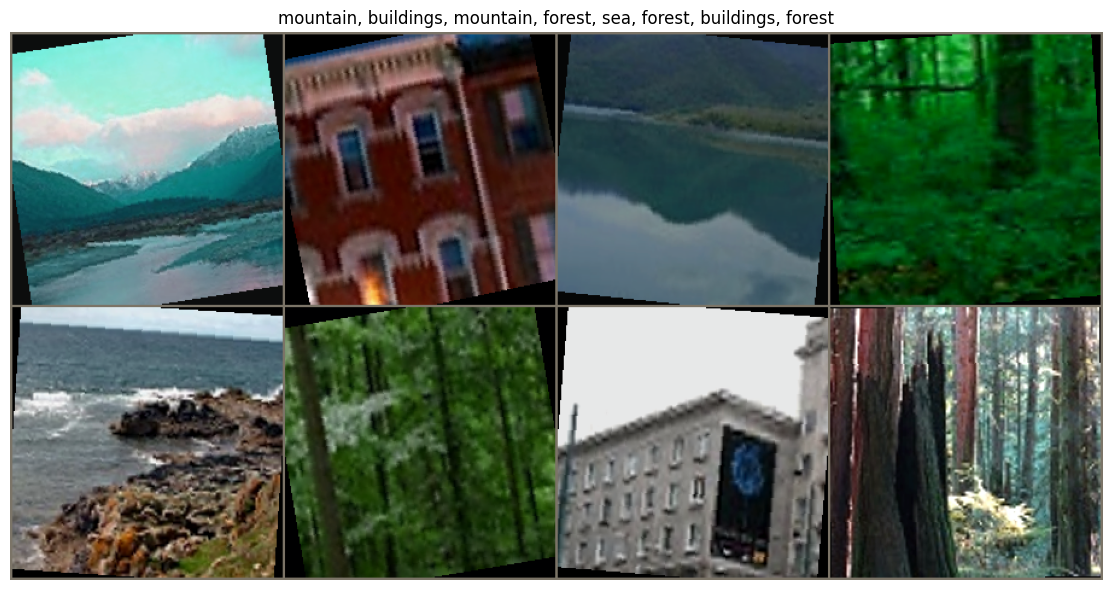

In [ ]:
import helper_utils
helper_utils.visualize_batch(train_loader, class_names).show()

<a name='3'></a>
## 3. Model Building

We'll use a pre-trained ResNet-18 model and adapt it for our 6-class classification task.

**Task:** Load a pre-trained ResNet-18 model and modify the final layer for 6 classes.

**Reference:**

- [PyTorch Transfer Learning Tutorial](https://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html)
- [torchvision.models](https://pytorch.org/vision/stable/models.html)
- [ResNet documentation](https://pytorch.org/vision/stable/models/generated/torchvision.models.resnet18.html)

In [ ]:
model_ft = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = model_ft.fc.in_features
model_ft.fc = nn.Linear(num_ftrs,len(class_names))
model_ft = model_ft.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 117MB/s]


<a name='4'></a>
## 4. Training

**Task:** Implement a training **function** and then train using two different transfer learning strategies.

**Reference:** [PyTorch Training Tutorial](https://docs.pytorch.org/tutorials/beginner/introyt/trainingyt.html#the-training-loop)

In [ ]:
def train_one_epoch(epoch_index, training_loader, model, optimizer, loss_fn, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    last_loss = 0.0

    for i, data in enumerate(training_loader):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        if i % 100 == 99:
            last_loss = running_loss / 100
            print(f'  Batch {i + 1} loss: {last_loss:.4f}')
            running_loss = 0.0

    train_acc = 100 * correct / total
    return last_loss, train_acc

def evaluate_model(model, dataloader, loss_fn, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(dataloader.dataset)
    val_acc = 100 * correct / total
    return epoch_loss, val_acc


<a name='4-1'></a>
### 4.1 ConvNet as Fixed Feature Extractor

In this approach, we freeze all the convolutional layers and only train the final classifier layer.

**Task:**

1. Load a fresh pre-trained model
2. Freeze all parameters except the final layer
3. Set up optimizer to only train the final layer
4. Train the model

In [ ]:
model_conv = models.resnet18(weights='IMAGENET1K_V1')

In [ ]:
for param in model_conv.parameters():
    param.requires_grad = False
num_ftrs = model_conv.fc.in_features
model_conv.fc = nn.Linear(num_ftrs, len(class_names))
model_conv = model_conv.to(device)

In [ ]:
optimizer_conv = optim.Adam(model_conv.fc.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

In [ ]:
history_conv = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
print("Starting Training : ")
for epoch in range(5):
    t_loss, t_acc = train_one_epoch(epoch, train_loader, model_conv, optimizer_conv, loss_fn, device)
    v_loss, v_acc = evaluate_model(model_conv, test_loader, loss_fn, device)
    history_conv['train_loss'].append(t_loss)
    history_conv['train_acc'].append(t_acc)
    history_conv['val_loss'].append(v_loss)
    history_conv['val_acc'].append(v_acc)
    print(f'Epoch:{epoch + 1} done with accuracy:{t_acc:.2f}% ')

Starting Training : 
  Batch 100 loss: 1.1802
  Batch 200 loss: 0.7718
  Batch 300 loss: 0.6857
  Batch 400 loss: 0.6216
Epoch:1 done with accuracy:70.99% 
  Batch 100 loss: 0.5841
  Batch 200 loss: 0.5808
  Batch 300 loss: 0.5991
  Batch 400 loss: 0.5845
Epoch:2 done with accuracy:77.95% 
  Batch 100 loss: 0.5555
  Batch 200 loss: 0.5704
  Batch 300 loss: 0.5517
  Batch 400 loss: 0.5663
Epoch:3 done with accuracy:79.34% 
  Batch 100 loss: 0.5585
  Batch 200 loss: 0.5389
  Batch 300 loss: 0.5326
  Batch 400 loss: 0.5598
Epoch:4 done with accuracy:79.61% 
  Batch 100 loss: 0.5391
  Batch 200 loss: 0.5175
  Batch 300 loss: 0.5428
  Batch 400 loss: 0.5414
Epoch:5 done with accuracy:80.03% 


**Quick Check**: Visualize training history

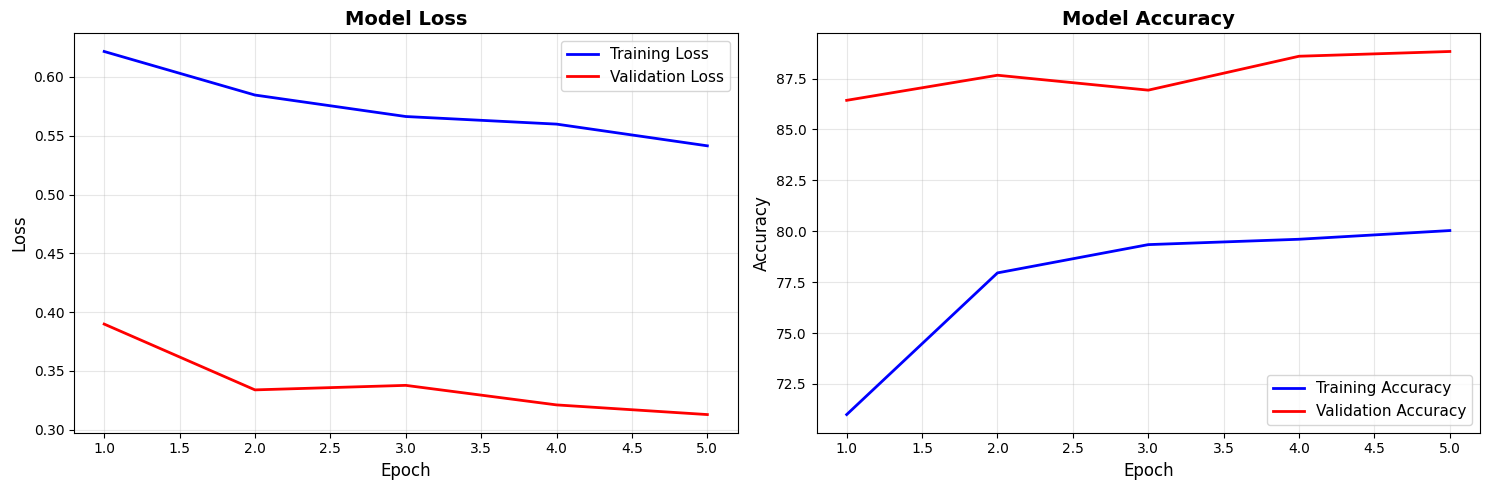

In [ ]:
helper_utils.visualize_training_history(history_conv).show()

**Quick Check**: Visualize predictions

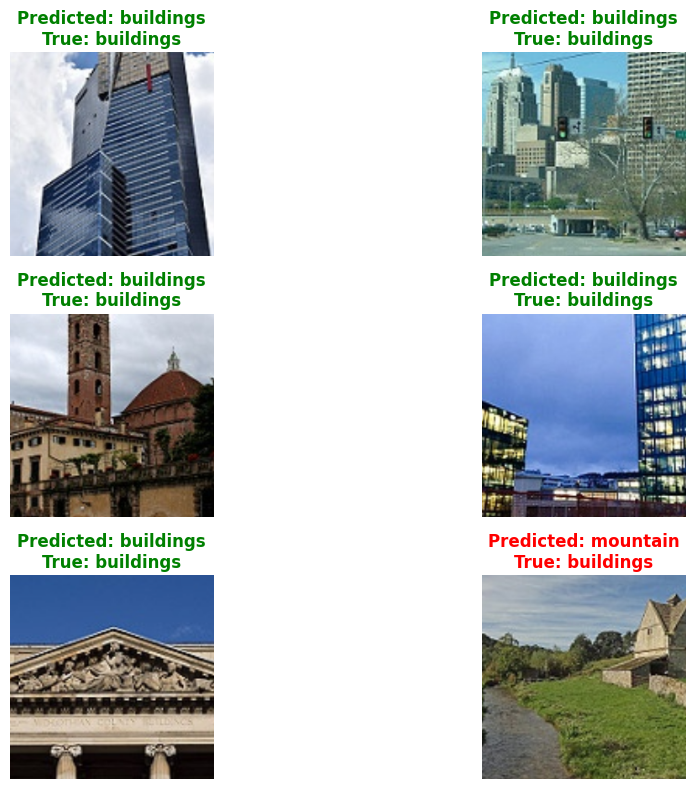

In [ ]:
helper_utils.visualize_predictions(model_conv,test_loader, class_names, device, num_images=6).show()

<a name='4-2'></a>
### 4.2 Fine-tuning the ConvNet

In this approach, we unfreeze all layers and train the entire network with a smaller learning rate.

**Task:**

1. Load a fresh pre-trained model
2. Modify the final layer
3. Set up optimizer for all parameters with a smaller learning rate
4. Train the model

In [ ]:
model_ft = models.resnet18(weights='IMAGENET1K_V1')

In [ ]:
num_ftrs = model_ft.fc.in_features
model_ft.fc = nn.Linear(num_ftrs, len(class_names))
model_ft = model_ft.to(device)

In [ ]:
optimizer_ft = torch.optim.Adam(model_ft.parameters(), lr=0.0001)
loss_fn = nn.CrossEntropyLoss()

In [ ]:
history_ft = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
print("Starting Training : ")
for epoch in range(5):
    t_loss2, t_acc2 = train_one_epoch(epoch, train_loader, model_ft, optimizer_ft, loss_fn, device)
    val_loss2, val_acc2 = evaluate_model(model_ft, test_loader, loss_fn, device)
    history_ft['train_loss'].append(t_loss2)
    history_ft['train_acc'].append(t_acc2)
    history_ft['val_loss'].append(val_loss2)
    history_ft['val_acc'].append(val_acc2)
    print(f'Epoch:{epoch + 1} done with train accuracy:{t_acc2:.2f}% , and valdition accuracy:{val_acc2:.2f}%')


Starting Training : 
  Batch 100 loss: 0.6553
  Batch 200 loss: 0.4802
  Batch 300 loss: 0.4586
  Batch 400 loss: 0.4460
Epoch:1 done with train accuracy:81.65% , and valdition accuracy:91.53%
  Batch 100 loss: 0.3894
  Batch 200 loss: 0.3860
  Batch 300 loss: 0.4045
  Batch 400 loss: 0.3961
Epoch:2 done with train accuracy:85.86% , and valdition accuracy:91.97%
  Batch 100 loss: 0.3288
  Batch 200 loss: 0.3799
  Batch 300 loss: 0.3655
  Batch 400 loss: 0.3368
Epoch:3 done with train accuracy:86.97% , and valdition accuracy:92.17%
  Batch 100 loss: 0.3393
  Batch 200 loss: 0.3420
  Batch 300 loss: 0.3468
  Batch 400 loss: 0.3356
Epoch:4 done with train accuracy:87.44% , and valdition accuracy:92.07%
  Batch 100 loss: 0.3067
  Batch 200 loss: 0.3229
  Batch 300 loss: 0.3266
  Batch 400 loss: 0.3132
Epoch:5 done with train accuracy:88.22% , and valdition accuracy:92.57%


**Quick Check**: Visualize training history

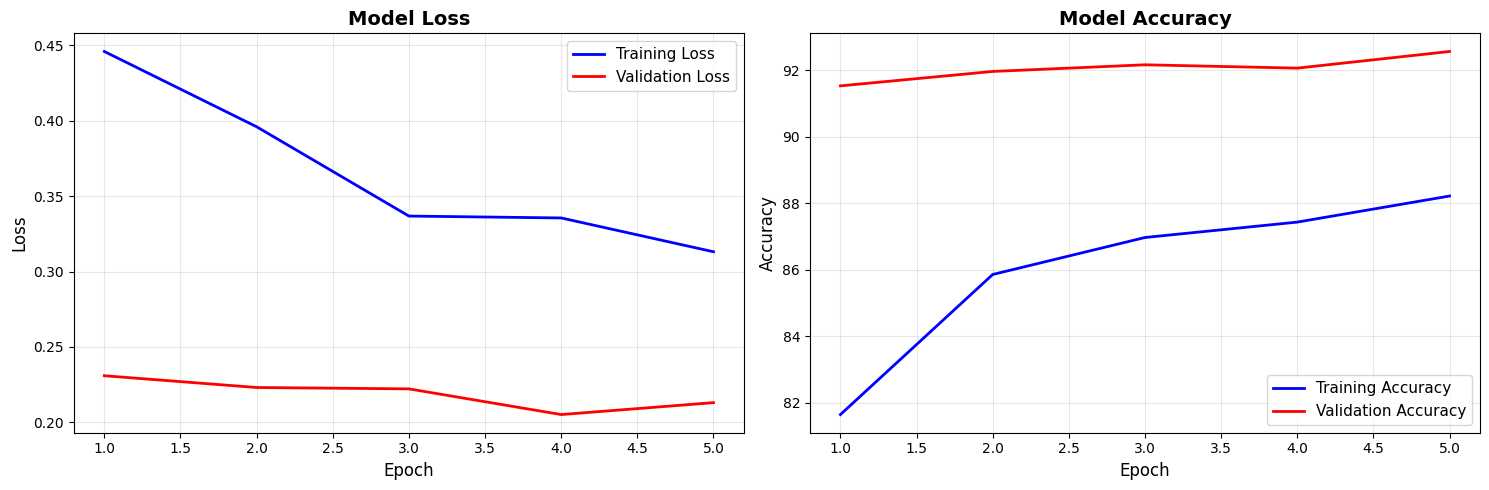

In [ ]:
 helper_utils.visualize_training_history(history_ft).show()

**Quick Check**: Visualize predictions

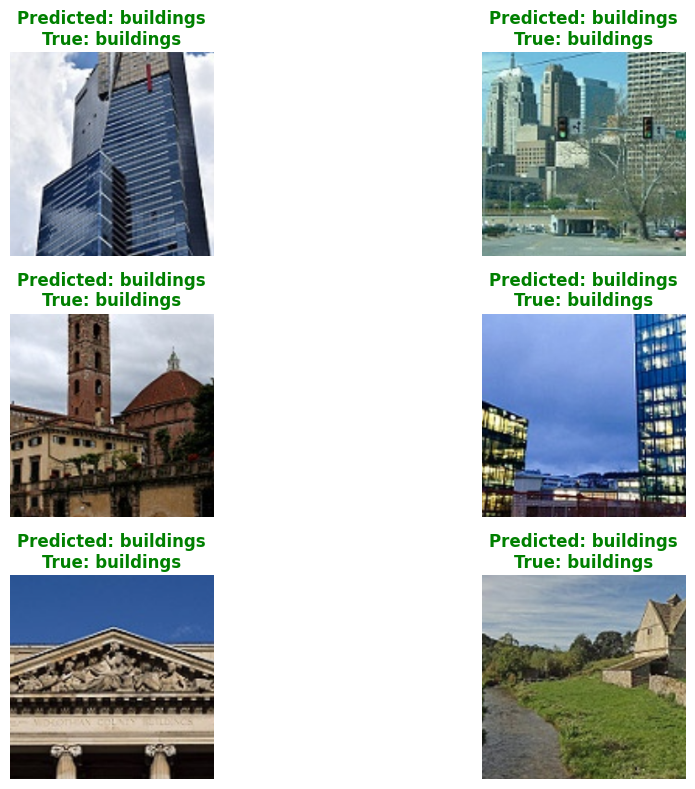

In [ ]:
helper_utils.visualize_predictions(model_ft,test_loader,class_names, device, num_images=6).show()

<a name='5'></a>
## 5. Evaluation

Compare the performance of both approaches.

**Task:** Evaluate both models and compare their performance metrics.

In [ ]:

print("Feature Extractor Approach:")
print(f"  Best Val Accuracy: {max(history_conv['val_acc']):.4f}")
print(f"  Final Val Accuracy: {history_conv['val_acc'][-1]:.4f}")

print("Fine-tuning Approach:")
print(f"  Best Val Accuracy: {max(history_ft['val_acc']):.4f}")
print(f"  Final Val Accuracy: {history_ft['val_acc'][-1]:.4f}")

Feature Extractor Approach:
  Best Val Accuracy: 88.8333
  Final Val Accuracy: 88.8333
Fine-tuning Approach:
  Best Val Accuracy: 92.5667
  Final Val Accuracy: 92.5667


<a name='6'></a>
## 6. Inference on Custom Images

Test your trained model on custom images.

**Task:** Load a custom image, preprocess it, and make a prediction using your trained model.

**Reference:** [Image Preprocessing](https://pytorch.org/vision/stable/transforms.html)

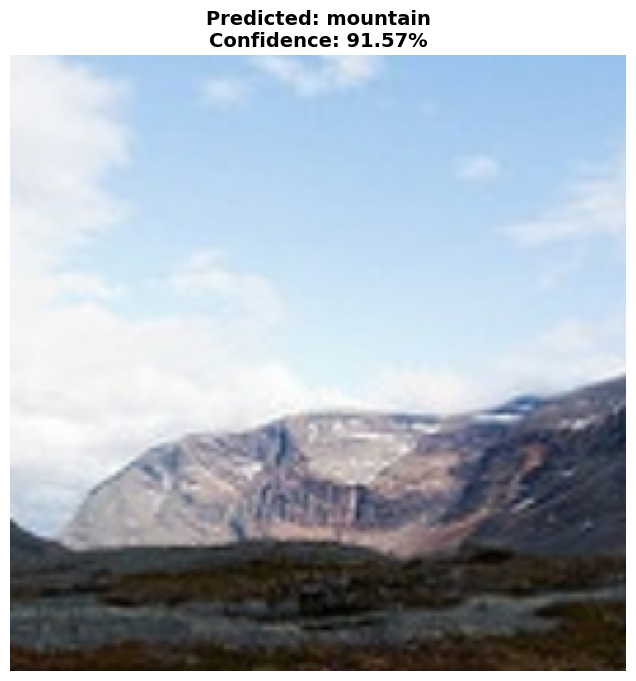

In [ ]:
# Make prediction on a custom image
img_path = '/content/seg_pred/seg_pred/10005.jpg'

# Use helper_utils.visualize_single_prediction or helper_utils.predict_single_image
helper_utils.visualize_single_prediction(
    model_ft,  # or model_conv
    img_path,
    test_dataset.transform,
    class_names,
    device
 ).show()

# 🏆🎉 Congratulations on completing the Weekly Final Project! 🎉🏆

Fantastic job on finishing the Weekly Final Project! You’ve put your skills to the test and made it to the end. Take a moment to celebrate your hard work and dedication. Keep up the great work and continue your learning journey!

<a name='7'></a>
## 7. Deployment (ONNX)

Convert your trained model to ONNX format for deployment.

**Task:**
1. Convert the PyTorch model to ONNX format
2. Load the ONNX model and perform inference

**Reference:**
- [PyTorch to ONNX](https://docs.pytorch.org/tutorials/beginner/onnx/export_simple_model_to_onnx_tutorial.html)

In [ ]:
!pip install onnx onnxscript onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 124.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 693.4/693.4 kB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 112.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.1/139.1 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 10.9 MB/s eta 0:00:00


In [ ]:
# Convert model to ONNX
# YOUR CODE HERE

# Set model to evaluation mode
model_ft.eval()

# Create dummy input (batch_size=1, channels=3, height=224, width=224)
dummy_input = torch.randn(1, 3, 224, 224).to(device)

# Export to ONNX
onnx_path = 'model.onnx'
torch.onnx.export(
     model_ft,
     dummy_input,
     onnx_path,
     input_names=['input'],
     output_names=['output'],
     dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}}
 )

print(f"Model exported to {onnx_path}")

/tmp/ipython-input-2700203691.py:12: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(


[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 40 of general pattern rewrite rules.
Model exported to model.onnx


In [ ]:
# Load ONNX model and perform inference
# YOUR CODE HERE
import onnxruntime as ort
import numpy as np
from PIL import Image
# Load ONNX model
ort_session = ort.InferenceSession(r'/content/model.onnx')

# Prepare input (use validation transform)
img_path = '/content/seg_pred/seg_pred/10013.jpg'
img = Image.open(img_path).convert('RGB')
img_tensor = test_dataset.transform(img).unsqueeze(0)
img_numpy = img_tensor.numpy()

# Run inference
outputs = ort_session.run(None, {'input': img_numpy})
predictions = np.array(outputs[0])
exp_preds = np.exp(predictions[0] - np.max(predictions[0]))
prob = exp_preds / exp_preds.sum()
pred_class_idx = np.argmax(prob)
pred_class = class_names[pred_class_idx]
confidence = prob[pred_class_idx]

print(f"Predicted: {pred_class} (confidence: {confidence:.2%})")

Predicted: mountain (confidence: 99.28%)
